In [36]:
import numpy as np 
import pandas as pd 

In [37]:
df = pd.read_csv('Iris.csv')

In [38]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [39]:
df = df.iloc[:,1:]

In [40]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
encoder = LabelEncoder()

In [43]:
df['Species'] = encoder.fit_transform(df['Species'])

In [44]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [45]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [46]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

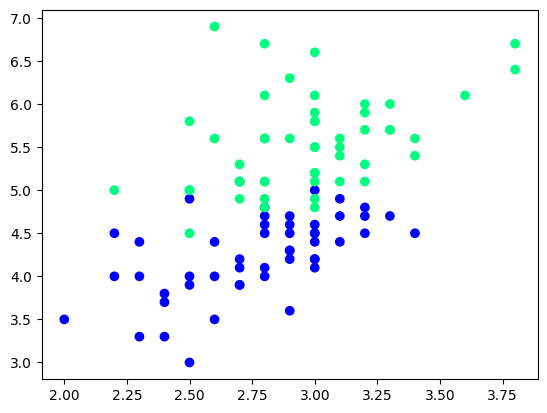

In [48]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [49]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
93,2.3,3.3,1
100,3.3,6.0,2
77,3.0,5.0,1
108,2.5,5.8,2
90,2.6,4.4,1
105,3.0,6.6,2
50,3.2,4.7,1
106,2.5,4.5,2
52,3.1,4.9,1
51,3.2,4.5,1


In [50]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [51]:
df_train

,SepalWidthCm,PetalLengthCm,Species
143,3.2,5.9,2
68,2.2,4.5,1
133,2.8,5.1,2
118,2.6,6.9,2
92,2.6,4.0,1
105,3.0,6.6,2
129,3.0,5.8,2
57,2.4,3.3,1
103,2.9,5.6,2
98,2.5,3.0,1


In [52]:
df_val

,SepalWidthCm,PetalLengthCm,Species
148,3.4,5.4,2
123,2.7,4.9,2
88,3.0,4.1,1
79,2.6,3.5,1
115,3.2,5.3,2


In [53]:
df_test

,SepalWidthCm,PetalLengthCm,Species
145,3.0,5.2,2
74,2.9,4.3,1
50,3.2,4.7,1
80,2.4,3.8,1
108,2.5,5.8,2


In [54]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [55]:
y_test

array([2, 2, 1, 1, 2])

# Case 1 - Bagging

In [56]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
143,3.2,5.9,2
103,2.9,5.6,2
57,2.4,3.3,1
92,2.6,4.0,1
129,3.0,5.8,2
129,3.0,5.8,2
103,2.9,5.6,2
103,2.9,5.6,2


In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [58]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

In [59]:
dt_bag1 = DecisionTreeClassifier()

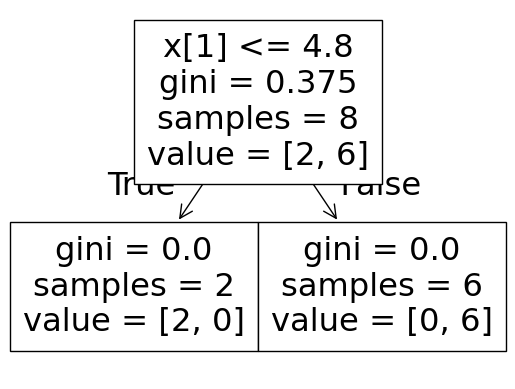

d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


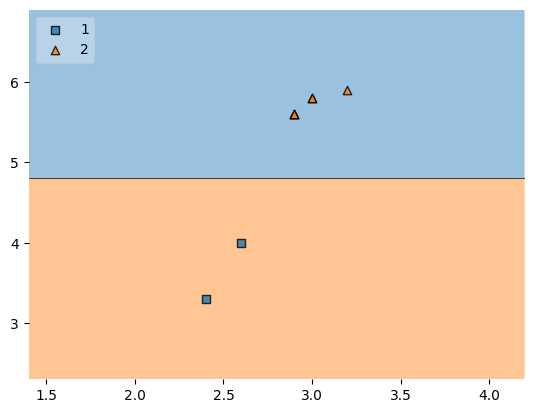

In [60]:
evaluate(dt_bag1,X,y)

In [61]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
92,2.6,4.0,1
68,2.2,4.5,1
129,3.0,5.8,2
57,2.4,3.3,1
57,2.4,3.3,1
105,3.0,6.6,2
103,2.9,5.6,2
103,2.9,5.6,2


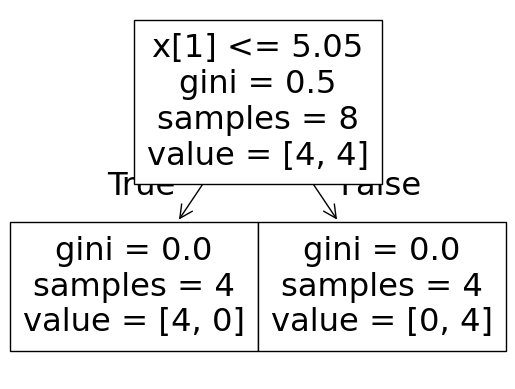

0.8


d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


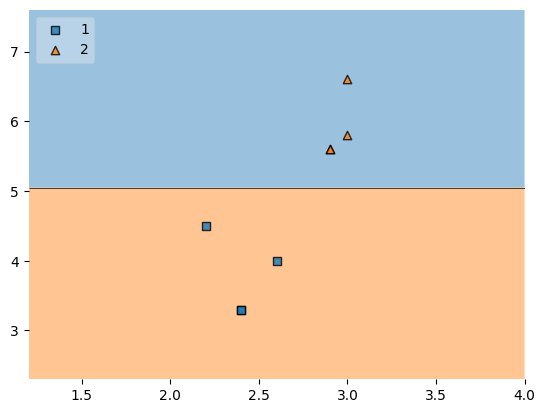

In [62]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [63]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
105,3.0,6.6,2
68,2.2,4.5,1
92,2.6,4.0,1
143,3.2,5.9,2
57,2.4,3.3,1
105,3.0,6.6,2
129,3.0,5.8,2
103,2.9,5.6,2


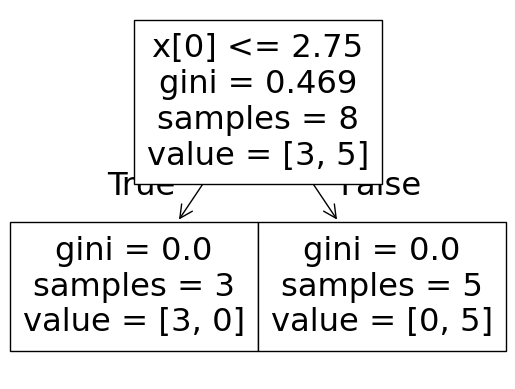

d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


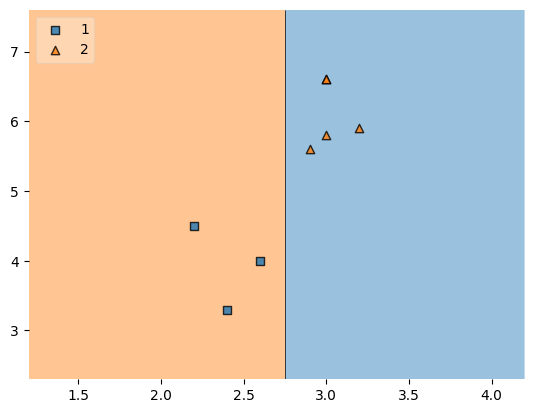

In [64]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [65]:
df_test

,SepalWidthCm,PetalLengthCm,Species
145,3.0,5.2,2
74,2.9,4.3,1
50,3.2,4.7,1
80,2.4,3.8,1
108,2.5,5.8,2


In [66]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [1]


d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [67]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
143,3.2,5.9,2
68,2.2,4.5,1
133,2.8,5.1,2
118,2.6,6.9,2
92,2.6,4.0,1
105,3.0,6.6,2
129,3.0,5.8,2
57,2.4,3.3,1
103,2.9,5.6,2
98,2.5,3.0,1


In [68]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
129,3.0,5.8,2
57,2.4,3.3,1
118,2.6,6.9,2
133,2.8,5.1,2
98,2.5,3.0,1
105,3.0,6.6,2
103,2.9,5.6,2
92,2.6,4.0,1


# Random Subspaces

In [70]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [71]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
85,86,6.0,3.4,4.5,1.6,Iris-versicolor
44,45,5.1,3.8,1.9,0.4,Iris-setosa
132,133,6.4,2.8,5.6,2.2,Iris-virginica
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
17,18,5.1,3.5,1.4,0.3,Iris-setosa
107,108,7.3,2.9,6.3,1.8,Iris-virginica
36,37,5.5,3.5,1.3,0.2,Iris-setosa
125,126,7.2,3.2,6.0,1.8,Iris-virginica
92,93,5.8,2.6,4.0,1.2,Iris-versicolor


In [72]:
df1.sample(2,replace=True,axis=1)

,SepalWidthCm,PetalLengthCm
85,3.4,4.5
44,3.8,1.9
132,2.8,5.6
5,3.9,1.7
6,3.4,1.4
17,3.5,1.4
107,2.9,6.3
36,3.5,1.3
125,3.2,6.0
92,2.6,4.0


# Random Patches

In [73]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
85,86,6.0,3.4,4.5,1.6,Iris-versicolor
44,45,5.1,3.8,1.9,0.4,Iris-setosa
132,133,6.4,2.8,5.6,2.2,Iris-virginica
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
17,18,5.1,3.5,1.4,0.3,Iris-setosa
107,108,7.3,2.9,6.3,1.8,Iris-virginica
36,37,5.5,3.5,1.3,0.2,Iris-setosa
125,126,7.2,3.2,6.0,1.8,Iris-virginica
92,93,5.8,2.6,4.0,1.2,Iris-versicolor


In [74]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalWidthCm,Id
107,2.9,108
125,3.2,126
5,3.9,6
5,3.9,6
5,3.9,6
92,2.6,93
132,2.8,133
17,3.5,18
